# Titanic disaster prediction

## Análisis y Preprocesamiento de los datos

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
train_data = pd.read_csv("./train.csv")

In [143]:
train_data.shape

(891, 12)

In [144]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [145]:
# nos quedamos unicamente con los features que nos importan
data = train_data.drop(["Name", "Ticket", "Cabin", "Embarked"], axis=1)
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
dtypes: float64(2), int64(5), object(1)
memory usage: 55.8+ KB


In [147]:
data["Sex"] = pd.Categorical(data["Sex"])
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Sex          891 non-null    category
 4   Age          714 non-null    float64 
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         891 non-null    float64 
dtypes: category(1), float64(2), int64(5)
memory usage: 49.8 KB


In [149]:
data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0


In [150]:
# vemos que hay valores faltantes en la columna de edad
# corregiremos eso, pero antes verificaremos si se trata de una clase en particular
na_age = data[data["Age"].isna()]
na_age.groupby("Pclass")["PassengerId"].count()

,PassengerId
Pclass,
1,30
2,11
3,136


In [151]:
# la mayoria de los que no tenemos registros de la edad corresponden a tercera clase
# es decir, la clase mas baja

# vamos a separar en grupos segun la clase y asignar las edades faltantes de acuerdo
# a la media de edades de cada clase
from sklearn.impute import SimpleImputer

def impute_by_group(group_data, strategy='mean'):
    imputer = SimpleImputer(strategy=strategy)
    return imputer.fit_transform(group_data.values.reshape(-1, 1)).flatten()

data['Age'] = data.groupby('Pclass')['Age'].transform(lambda x: impute_by_group(x, strategy='mean'))
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [152]:
data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


### Pequeño paréntesis con pruebas de rangos

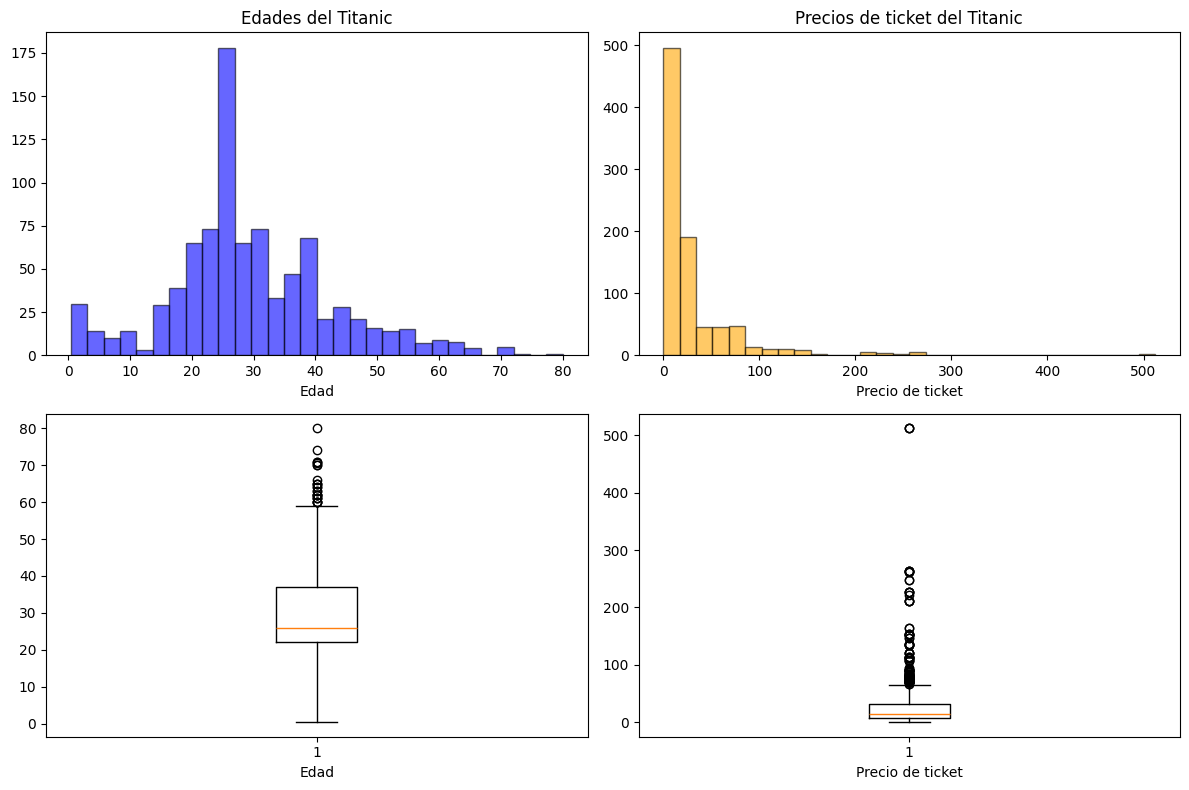

In [153]:
# Analicemos la edad y el valor de ticket para separar en rangos
data_copy = data.copy()

fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0, 0].hist(data_copy["Age"], bins=30, alpha=0.6, color='blue', edgecolor='black')
ax[0, 0].set_title("Edades del Titanic")
ax[0, 0].set_xlabel("Edad")

ax[0, 1].hist(data_copy["Fare"], bins=30, alpha=0.6, color='orange', edgecolor='black')
ax[0, 1].set_title("Precios de ticket del Titanic")
ax[0, 1].set_xlabel("Precio de ticket")

ax[1, 0].boxplot(data_copy["Age"])
ax[1, 0].set_xlabel("Edad")

ax[1, 1].boxplot(data_copy["Fare"])
ax[1, 1].set_xlabel("Precio de ticket")

plt.tight_layout()

plt.show()

In [154]:
# vamos a discretizar con rangos las edades y el precio del ticket

bins_age = [0, 12, 18, 35, 60, 100]
labels_age = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Old Adult']

bins_fare = [0, 50, 100, 200, 500]
labels_fare = ["Cheap", "Medium", "Expensive", "Most Expensive"]

data_copy["Age"] = pd.cut(data_copy["Age"], bins=bins_age, labels=labels_age, right=False)
data_copy["Fare"] = pd.cut(data_copy["Fare"], bins=bins_fare, labels=labels_fare, right=False)

data_copy.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,Young Adult,1,0,Cheap
1,2,1,1,female,Adult,1,0,Medium
2,3,1,3,female,Young Adult,0,0,Cheap
3,4,1,1,female,Adult,1,0,Medium
4,5,0,3,male,Adult,0,0,Cheap


In [155]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Sex          891 non-null    category
 4   Age          891 non-null    category
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         888 non-null    category
dtypes: category(3), int64(5)
memory usage: 38.1 KB


In [156]:
data_copy["Fare"].value_counts()

,count
Fare,
Cheap,730
Medium,108
Expensive,33
Most Expensive,17


In [157]:
data_copy["Age"].value_counts()

,count
Age,
Young Adult,513
Adult,239
Child,68
Teenager,45
Old Adult,26


Si quisiéramos utilizar nuestros datos según se encuentran en ```data_copy```para analizar la matriz de correlación por ejemplo, deberíamos convertir las columnas categóricas a numéricas, como lo hacemos justo aquí abajo con la original.

### Proseguimos

In [158]:
from sklearn.preprocessing import LabelEncoder

In [160]:
encoder = LabelEncoder()
data["Age"] = encoder.fit_transform(data["Age"])
data["Fare"] = encoder.fit_transform(data["Fare"])
data["Sex"] = encoder.fit_transform(data["Sex"])

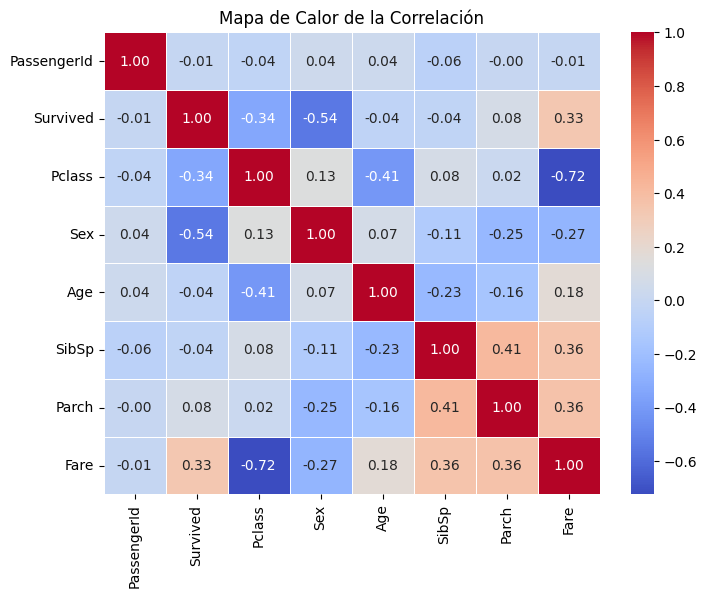

In [161]:
correlation_matrix = data.corr()

# Dibujar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Mostrar el gráfico
plt.title("Mapa de Calor de la Correlación")
plt.show()

In [162]:
# Por el mapa de calor vemos que la tasa de supervivencia está más fuertemente
# vinculada con el sexo del pasajero y en un poco menor medida con la clase

# Por otro lado, vemos que ciertas columnas como el id del pasajero, Sibsp y Parch
# no aportan una relacion significativa con el indice de supervivencia
# Podriamos prescindir de dichas columnas

data = data.drop(["PassengerId", "SibSp", "Parch"], axis=1)
data.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,28,18
1,1,1,0,53,207
2,1,3,0,35,41
3,1,1,0,49,189
4,0,3,1,49,43


## Entrenamiento del modelo

Este es un caso de clasificación binaria. Vamos a probar diferentes modelos de clasificación, con distintas pruebas de hiperparámetros y, en base a las métricas que nos arroje cada uno, elegiremos uno u otro.

In [163]:
!pip install xgboost

In [170]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [169]:
# Primero vamos a escalar los datos
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
scaled_data.head()

,Survived,Pclass,Sex,Age,Fare
0,0.0,1.0,1.0,0.311111,0.072874
1,1.0,0.0,0.0,0.588889,0.838057
2,1.0,1.0,0.0,0.388889,0.165992
3,1.0,0.0,0.0,0.544444,0.765182
4,0.0,1.0,1.0,0.544444,0.174089


In [184]:
# Ahora probaremos distintos modelos con diferentes parametros
# Almacenaremos los resultados para posterior analisis

modelos = {
    "DecisionTree": (DecisionTreeClassifier(), {
        "max_depth": [3, 5, 10],
        "criterion": ["gini", "entropy"]
    }),
    "RandomForest": (RandomForestClassifier(), {
        "n_estimators": [10, 50, 100],
        "max_depth": [3, 5, 10]
    }),
    "LogisticRegression": (LogisticRegression(), {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    }),
    "SVC": (SVC(), {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    }),
    "XGBoost": (XGBClassifier(use_label_encoder=False, eval_metric="mlogloss"), {
        "n_estimators": [10, 50, 100],
        "max_depth": [3, 5, 10]
    })
}

X = scaled_data.drop(["Survived"], axis=1)
y = scaled_data["Survived"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [187]:
def recorrer_modelos(modelos, X, y):
  resultados = {
    "name": [],
    "best_estimator": [],
    "best_params": [],
    "best_score": []
  }
  for model_name, (model, model_params) in modelos.items():
    print(f"Probando estimador {model_name}...")
    grid_search = GridSearchCV(estimator=model,
                               param_grid=model_params,
                               scoring="accuracy",
                               cv=5, # croos validation con 5 partes
                               n_jobs=-1)
    grid_search.fit(X.values, y.values)
    best_estimator = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    resultados["name"].append(model_name)
    resultados["best_estimator"].append(best_estimator)
    resultados["best_params"].append(best_params)
    resultados["best_score"].append(best_score)
  return resultados

In [191]:
results = recorrer_modelos(modelos, X, y)
#results

Probando estimador DecisionTree...
Probando estimador RandomForest...
Probando estimador LogisticRegression...
Probando estimador SVC...
Probando estimador KNN...
Probando estimador XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:36:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [194]:
models_df = pd.DataFrame(results)
models_df

,name,best_estimator,best_params,best_score
0,DecisionTree,"DecisionTreeClassifier(criterion='entropy', ma...","{'criterion': 'entropy', 'max_depth': 3}",0.815931
1,RandomForest,"(DecisionTreeClassifier(max_depth=10, max_feat...","{'max_depth': 10, 'n_estimators': 50}",0.835039
2,LogisticRegression,LogisticRegression(C=1),"{'C': 1, 'solver': 'lbfgs'}",0.792361
3,SVC,SVC(C=10),"{'C': 10, 'kernel': 'rbf'}",0.817042
4,KNN,KNeighborsClassifier(),"{'n_neighbors': 5, 'weights': 'uniform'}",0.813703
5,XGBoost,"XGBClassifier(base_score=None, booster=None, c...","{'max_depth': 3, 'n_estimators': 50}",0.845138


In [197]:
models_df['best_score'].max()

0.8451384093904964

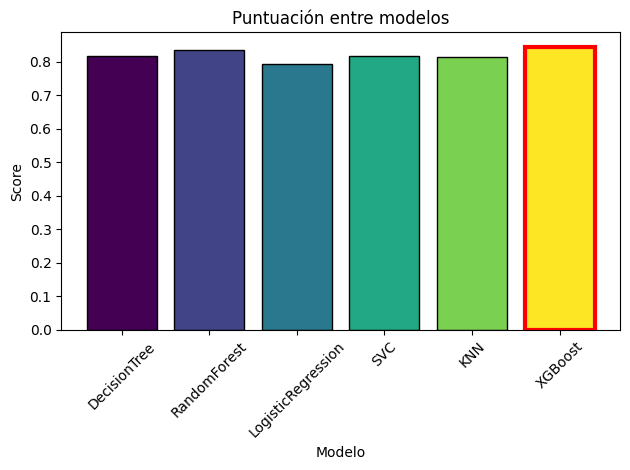

In [201]:
# Encontrar el índice de la barra con el valor más alto
max_index = models_df['best_score'].idxmax()
colores = plt.cm.viridis(np.linspace(0, 1, models_df.shape[0]))

plt.bar(models_df['name'], models_df['best_score'],
        color=colores,
        edgecolor=['black' if i != max_index else 'red' for i in models_df.index],
        linewidth=[1 if i != max_index else 3 for i in models_df.index])


plt.xticks(rotation=45)
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.title("Puntuación entre modelos")

plt.tight_layout()

plt.show()


Vemos que el modelo que ha obtenido la mejor clasificación ha sido el de XGBoost.

In [204]:
model_index = models_df[models_df["name"] == "XGBoost"].index[0]
model = results["best_estimator"][model_index]
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

## Generamos predicciones

In [205]:
test_data = pd.read_csv("./test.csv")

In [206]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Vamos a reproducir el preprocesamiento hecho antes. Más adelante veremos cómo se puede automatizar en un pipeline.

In [207]:
X_test = test_data[['Pclass', 'Sex', 'Age', 'Fare']]

X_test.isna().sum()

,0
Pclass,0
Sex,0
Age,86
Fare,1


In [208]:
X_test['Age'] = X_test.groupby('Pclass')['Age'].transform(lambda x: impute_by_group(x, strategy='mean'))
X_test['Fare'] = X_test.groupby('Pclass')['Fare'].transform(lambda x: impute_by_group(x, strategy='mean'))

<ipython-input-208-1743f07eece3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Age'] = X_test.groupby('Pclass')['Age'].transform(lambda x: impute_by_group(x, strategy='mean'))
<ipython-input-208-1743f07eece3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Fare'] = X_test.groupby('Pclass')['Fare'].transform(lambda x: impute_by_group(x, strategy='mean'))


In [209]:
X_test.isna().sum()

,0
Pclass,0
Sex,0
Age,0
Fare,0


In [210]:
encoder = LabelEncoder()
X_test["Age"] = encoder.fit_transform(X_test["Age"])
X_test["Fare"] = encoder.fit_transform(X_test["Fare"])
X_test["Sex"] = encoder.fit_transform(X_test["Sex"])

<ipython-input-210-44e6640d47ba>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Age"] = encoder.fit_transform(X_test["Age"])
<ipython-input-210-44e6640d47ba>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Fare"] = encoder.fit_transform(X_test["Fare"])
<ipython-input-210-44e6640d47ba>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

In [211]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(X_test)
scaled_data = pd.DataFrame(scaled_data, columns=X_test.columns)

In [212]:
y_pred = model.predict(scaled_data)

In [213]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [215]:
predictions = {
    "PassengerId": test_data["PassengerId"].values,
    "Survived": y_pred
}

predictions_df = pd.DataFrame(predictions)
predictions_df.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [216]:
# Exportamos los resultados
predictions_df.to_csv("titanic_predictions.csv", index=False)